**Nitheeswaran M 24BAD079**

**Scenario 1**

In [9]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('/kaggle/input/datasets/heeraldedhia/groceries-dataset/Groceries_dataset.csv')

transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).values.tolist()

In [3]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Dataset Dimensions: {df_encoded.shape}")
print(df_encoded.head())

Dataset Dimensions: (14963, 167)
   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False  False    False   
2           False  False          False             False  False    False   
3           False  False          False             False  False    False   
4           False  False          False             False  False    False   

   ...  turkey  vinegar  waffles  whipped/sour cream  whisk

In [6]:
min_support = 0.001 
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

filtered_rules = rules[rules['confidence'] > 0.05].sort_values(by='lift', ascending=False)

print(f"Total rules found: {len(rules)}")
print(f"Rules after filtering: {len(filtered_rules)}")

Total rules found: 240
Rules after filtering: 94


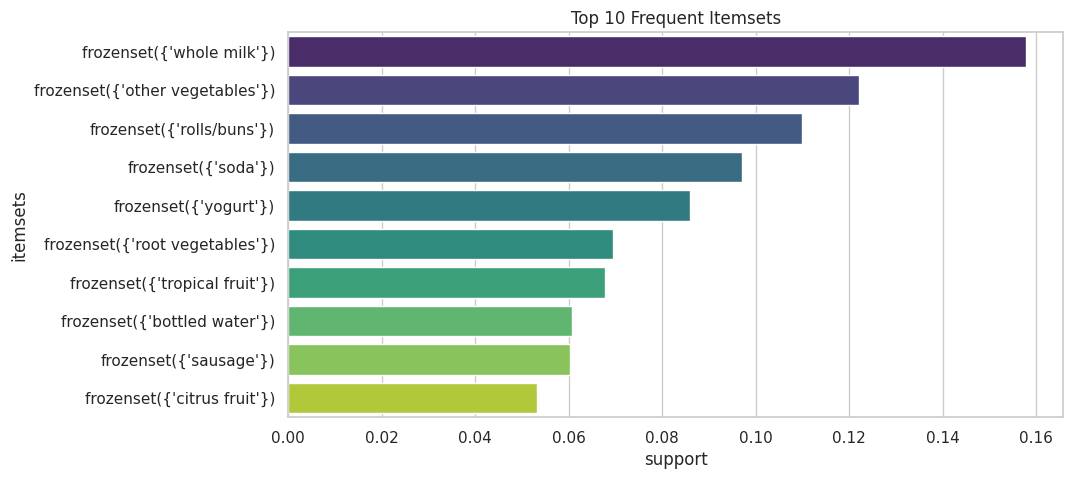

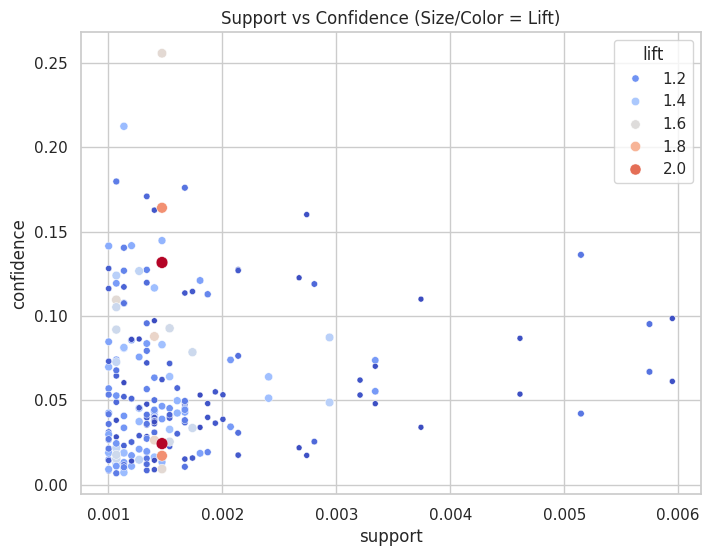

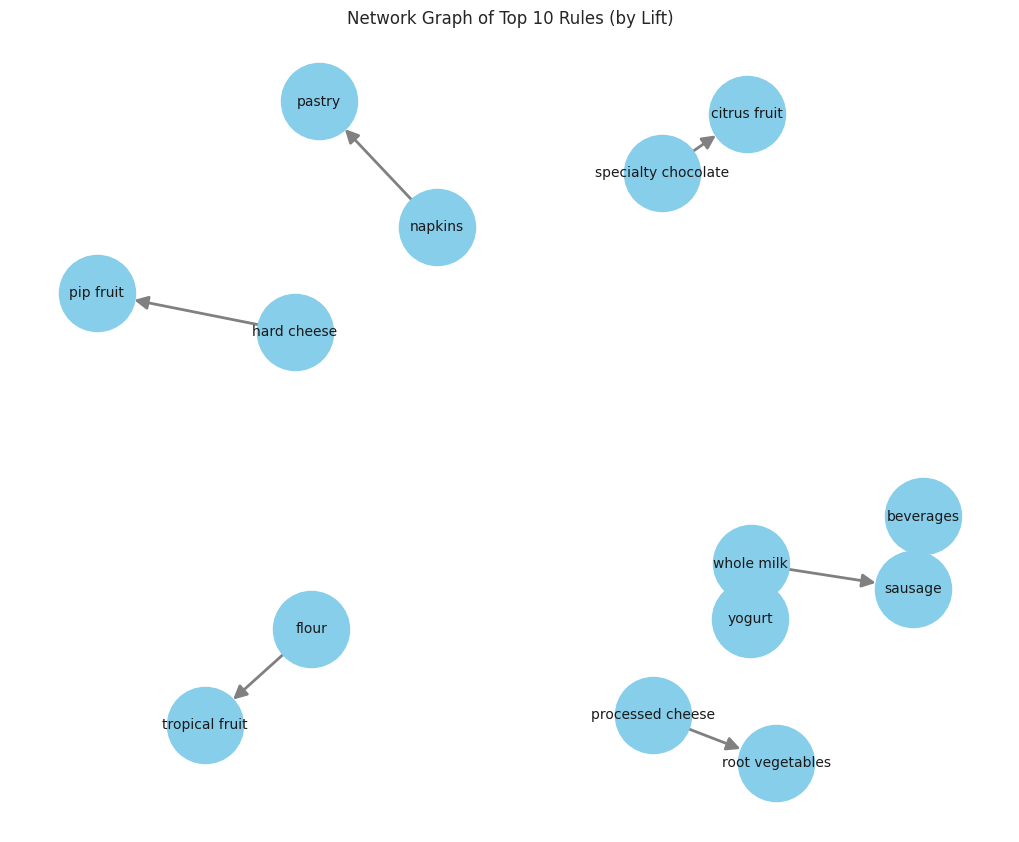

Nitheeswaran M 24BAD079


In [8]:
plt.figure(figsize=(10, 5))
top_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).head(10)
sns.barplot(x='support', y='itemsets', data=top_itemsets, palette='viridis')
plt.title('Top 10 Frequent Itemsets')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='support', y='confidence', size='lift', data=rules, hue='lift', palette='coolwarm')
plt.title('Support vs Confidence (Size/Color = Lift)')
plt.grid(True)
plt.show()

import networkx as nx

def plot_network(rules_df, num_rules=10):
    G = nx.DiGraph()
    subset = rules_df.head(num_rules)
    
    for i, row in subset.iterrows():
        ant = list(row['antecedents'])[0]
        con = list(row['consequents'])[0]
        G.add_edge(ant, con, weight=row['lift'])

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=3000, 
            edge_color='gray', font_size=10, width=2, arrowsize=20)
    plt.title(f'Network Graph of Top {num_rules} Rules (by Lift)')
    plt.show()

plot_network(filtered_rules)
print("Nitheeswaran M 24BAD079")

**Scenario 2**

In [10]:
wine_data = load_wine(as_frame=True)
df = wine_data.frame
X = wine_data.data
y = wine_data.target 

print(f"Original Dataset Shape: {X.shape} (13 features!)")

Original Dataset Shape: (178, 13) (13 features!)


In [11]:
if X.isnull().sum().sum() > 0:
    X = X.dropna()
    
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

PCA()

In [12]:
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

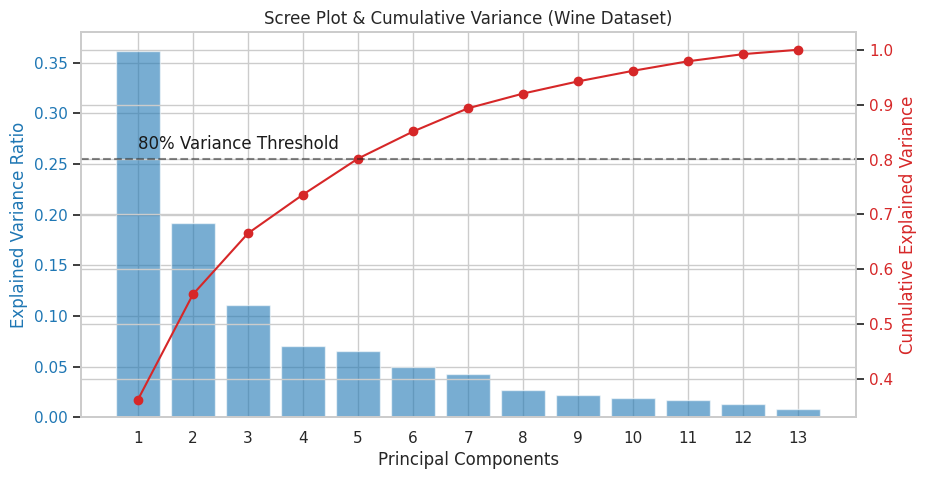

In [13]:
fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(range(1, len(explained_variance) + 1), explained_variance, 
               alpha=0.6, color='tab:blue', label='Individual Explained Variance')
ax1.set_xlabel('Principal Components')
ax1.set_ylabel('Explained Variance Ratio', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
line = ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
                marker='o', linestyle='-', color='tab:red', label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.axhline(y=0.80, color='k', linestyle='--', alpha=0.5) 
ax2.text(1, 0.82, '80% Variance Threshold', color='k')

plt.title('Scree Plot & Cumulative Variance (Wine Dataset)')
plt.xticks(range(1, len(explained_variance) + 1))
plt.show()

In [15]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("\nDIMENSION REDUCTION RESULTS")
print(f"Reduced Dataset Shape: {X_pca_2d.shape}")
print(f"Variance captured by PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"Variance captured by PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Total variance captured in 2D: {np.sum(pca_2d.explained_variance_ratio_):.4f}\n")


DIMENSION REDUCTION RESULTS
Reduced Dataset Shape: (178, 2)
Variance captured by PC1: 0.3620
Variance captured by PC2: 0.1921
Total variance captured in 2D: 0.5541



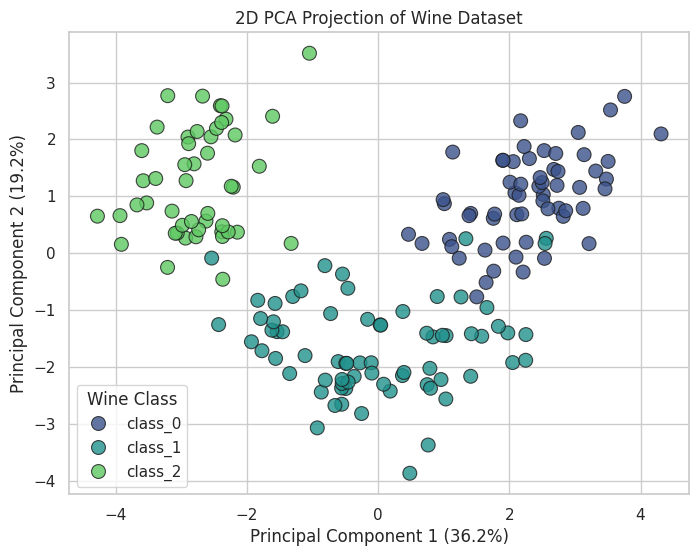

Nitheeswaran M 24BAD079


In [17]:
plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    x=X_pca_2d[:, 0], 
    y=X_pca_2d[:, 1], 
    hue=wine_data.target_names[y], 
    palette='viridis', 
    s=100, 
    alpha=0.8,
    edgecolor='k'
)
plt.title('2D PCA Projection of Wine Dataset')
plt.xlabel(f'Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Wine Class')
plt.show()
print("Nitheeswaran M 24BAD079")